# Policy Distribution per Role (Selected Baseline Datasets)

This notebook analyzes **policy-per-role distribution** on the requested baseline datasets in `data/selected`:

1. `spider/column_level_rbac_dataset_spider_20260113.json`
2. `bird/column_level_rbac_dataset_bird_20251230.json`
3. `livesqlbench-full/crud_rbac_dataset_v2_20251230.json`

**Note:** All downstream statistics/plots/tables exclude `SystemManager` because it is injected for every query by design.

In [11]:
from pathlib import Path
import json
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ANALYSIS_ROOT = PROJECT_ROOT / 'outputs' / 'analysis'

runs = sorted(ANALYSIS_ROOT.glob('policy_distribution_selected_*'))
assert runs, f'No analysis runs found under {ANALYSIS_ROOT}'
LATEST = runs[-1]
print('Using analysis run:', LATEST)

role_dist_path = LATEST / 'role_distribution.csv'
role_stats_path = LATEST / 'role_policy_stats.csv'
summary_path = LATEST / 'summary.json'

role_dist = pd.read_csv(role_dist_path)
role_stats = pd.read_csv(role_stats_path)
with open(summary_path, 'r', encoding='utf-8') as f:
    summary = json.load(f)

# Exclude SystemManager (always injected per query by dataset design)
role_dist_nosm = role_dist[role_dist['role'] != 'SystemManager'].copy()
role_stats_nosm = role_stats[role_stats['role'] != 'SystemManager'].copy()

print('role_dist rows:', len(role_dist), '-> no SystemManager:', len(role_dist_nosm))
print('role_stats rows:', len(role_stats), '-> no SystemManager:', len(role_stats_nosm))

role_dist_nosm.head(), role_stats_nosm.head()

Using analysis run: /home/feiy/Role-SQL-benchmark/outputs/analysis/policy_distribution_selected_20260314_193939
role_dist rows: 202 -> no SystemManager: 199
role_stats rows: 202 -> no SystemManager: 199


(                      dataset         level                        role  \
 0  bird_column_level_20251230  column_level  AcademicPerformanceAnalyst   
 1  bird_column_level_20251230  column_level              AccountManager   
 2  bird_column_level_20251230  column_level              BettingAnalyst   
 3  bird_column_level_20251230  column_level          CardCatalogManager   
 4  bird_column_level_20251230  column_level              ClientServices   
 
    sample_count  unique_policy_count  unique_policy_ratio  
 0            89                    1             0.011236  
 1           106                    1             0.009434  
 2           129                    1             0.007752  
 3           191                    1             0.005236  
 4           106                    1             0.009434  ,
                       dataset  ddl_rate  delete_tables_mean  \
 0  bird_column_level_20251230       NaN                 NaN   
 1  bird_column_level_20251230       NaN       

## Dataset Overview

In [2]:
overview = pd.DataFrame(summary['dataset_overview'])
overview

,dataset,level,path,sample_count,role_count
0,spider_column_level_20260113,column_level,/home/feiy/Role-SQL-benchmark/data/selected/sp...,5047,71
1,bird_column_level_20251230,column_level,/home/feiy/Role-SQL-benchmark/data/selected/bi...,7252,43
2,livesqlbench_crud_level_20251230,crud_level,/home/feiy/Role-SQL-benchmark/data/selected/li...,3217,88


## Role Distribution (samples and unique policy templates)

In [12]:
role_dist_nosm.sort_values(['dataset', 'sample_count'], ascending=[True, False]).head(30)

,dataset,level,role,sample_count,unique_policy_count,unique_policy_ratio
3,bird_column_level_20251230,column_level,CardCatalogManager,191,1,0.005236
17,bird_column_level_20251230,column_level,GameRulesSpecialist,191,1,0.005236
21,bird_column_level_20251230,column_level,LocalizationCoordinator,191,1,0.005236
23,bird_column_level_20251230,column_level,MarketplaceAnalyst,191,1,0.005236
8,bird_column_level_20251230,column_level,CommunityModerator,186,1,0.005376
10,bird_column_level_20251230,column_level,ContentAnalyst,186,1,0.005376
40,bird_column_level_20251230,column_level,TagCurator,186,1,0.005376
42,bird_column_level_20251230,column_level,UserSupportSpecialist,186,1,0.005376
14,bird_column_level_20251230,column_level,DriverManager,174,1,0.005747
32,bird_column_level_20251230,column_level,PublicRelations,174,1,0.005747


In [13]:
role_dist_nosm.groupby(['dataset', 'level']).agg(
    roles=('role', 'count'),
    total_samples=('sample_count', 'sum'),
    avg_samples_per_role=('sample_count', 'mean'),
    avg_unique_policies=('unique_policy_count', 'mean')
).reset_index()

,dataset,level,roles,total_samples,avg_samples_per_role,avg_unique_policies
0,bird_column_level_20251230,column_level,42,5718,136.142857,1.000000
1,livesqlbench_crud_level_20251230,crud_level,87,2625,30.172414,1.114943
2,spider_column_level_20260113,column_level,70,4013,57.328571,1.085714


## Policy Complexity per Role

In [5]:
role_stats.columns.tolist()

['dataset',
 'ddl_rate',
 'delete_tables_mean',
 'insert_tables_mean',
 'level',
 'policy_items_max',
 'policy_items_mean',
 'policy_items_median',
 'policy_items_min',
 'policy_items_p90',
 'role',
 'sample_count',
 'select_items_mean',
 'table_count_mean',
 'update_items_mean',
 'wildcard_tables_mean']

In [14]:
# Column-level: policy_items roughly equals total accessible column entries (with '*' as 1 token).
col_stats = role_stats_nosm[role_stats_nosm['level'] == 'column_level'].copy()
col_stats.sort_values(['dataset', 'policy_items_mean'], ascending=[True, False]).head(30)

,dataset,ddl_rate,delete_tables_mean,insert_tables_mean,level,policy_items_max,policy_items_mean,policy_items_median,policy_items_min,policy_items_p90,role,sample_count,select_items_mean,table_count_mean,update_items_mean,wildcard_tables_mean
24,bird_column_level_20251230,NaN,NaN,NaN,column_level,96,96.0,96.0,96,96.0,MatchDataRecorder,129,NaN,5.0,NaN,0.0
33,bird_column_level_20251230,NaN,NaN,NaN,column_level,61,61.0,61.0,61,61.0,RaceAnalyst,174,NaN,8.0,NaN,0.0
6,bird_column_level_20251230,NaN,NaN,NaN,column_level,60,60.0,60.0,60,60.0,ClinicalResearcher,163,NaN,3.0,NaN,0.0
37,bird_column_level_20251230,NaN,NaN,NaN,column_level,54,54.0,54.0,54,54.0,Scout,129,NaN,5.0,NaN,0.0
10,bird_column_level_20251230,NaN,NaN,NaN,column_level,52,52.0,52.0,52,52.0,ContentAnalyst,186,NaN,8.0,NaN,0.0
39,bird_column_level_20251230,NaN,NaN,NaN,column_level,50,50.0,50.0,50,50.0,TacticalAnalyst,129,NaN,5.0,NaN,0.0
2,bird_column_level_20251230,NaN,NaN,NaN,column_level,49,49.0,49.0,49,49.0,BettingAnalyst,129,NaN,4.0,NaN,0.0
8,bird_column_level_20251230,NaN,NaN,NaN,column_level,49,49.0,49.0,49,49.0,CommunityModerator,186,NaN,8.0,NaN,3.0
23,bird_column_level_20251230,NaN,NaN,NaN,column_level,47,47.0,47.0,47,47.0,MarketplaceAnalyst,191,NaN,3.0,NaN,0.0
36,bird_column_level_20251230,NaN,NaN,NaN,column_level,44,44.0,44.0,44,44.0,SchoolRegistrySpecialist,89,NaN,1.0,NaN,0.0


In [15]:
# CRUD-level: policy_items = DDL + INSERT tables + DELETE tables + SELECT items + UPDATE items
crud_stats = role_stats_nosm[role_stats_nosm['level'] == 'crud_level'].copy()
crud_stats.sort_values('policy_items_mean', ascending=False).head(30)

,dataset,ddl_rate,delete_tables_mean,insert_tables_mean,level,policy_items_max,policy_items_mean,policy_items_median,policy_items_min,policy_items_p90,role,sample_count,select_items_mean,table_count_mean,update_items_mean,wildcard_tables_mean
54,livesqlbench_crud_level_20251230,0.0,0.0,3.0000,crud_level,114,114.0000,114.0,114,114.0,ClinicalAssessor,26,70.0000,NaN,41.0000,NaN
72,livesqlbench_crud_level_20251230,0.0,0.0,0.0000,crud_level,97,97.0000,97.0,97,97.0,EquipmentOperator,30,89.0000,NaN,8.0000,NaN
55,livesqlbench_crud_level_20251230,0.0,0.0,5.0000,crud_level,94,94.0000,94.0,94,94.0,ClinicalCareCoordinator,26,65.0000,NaN,24.0000,NaN
43,livesqlbench_crud_level_20251230,0.0,0.0,4.0000,crud_level,86,86.0000,86.0,86,86.0,AllocationOfficer,30,49.0000,NaN,33.0000,NaN
86,livesqlbench_crud_level_20251230,0.0,0.0,1.4416,crud_level,134,82.1429,65.0,40,134.0,MaintenanceTechnician,77,53.8961,NaN,26.8052,NaN
126,livesqlbench_crud_level_20251230,0.0,0.0,2.0000,crud_level,81,81.0000,81.0,81,81.0,TreatmentProvider,26,66.0000,NaN,13.0000,NaN
107,livesqlbench_crud_level_20251230,0.0,4.0,4.0000,crud_level,76,76.0000,76.0,76,76.0,RiskAndMaintenanceManager,30,13.0000,NaN,55.0000,NaN
103,livesqlbench_crud_level_20251230,0.0,0.0,0.0000,crud_level,86,73.6786,63.0,63,86.0,ResearchAnalyst,56,73.6786,NaN,0.0000,NaN
92,livesqlbench_crud_level_20251230,0.0,1.0,2.0000,crud_level,69,69.0000,69.0,69,69.0,PlantManager,30,51.0000,NaN,15.0000,NaN
52,livesqlbench_crud_level_20251230,0.0,1.0,2.0000,crud_level,91,66.5000,66.5,42,91.0,CaseManager,56,35.5000,NaN,28.0000,NaN


## Compact Report Table

In [16]:
report = role_stats_nosm.groupby(['dataset', 'level']).agg(
    roles=('role', 'count'),
    samples=('sample_count', 'sum'),
    mean_policy_items=('policy_items_mean', 'mean'),
    median_policy_items=('policy_items_median', 'median'),
    max_policy_items=('policy_items_max', 'max')
).reset_index()
report

,dataset,level,roles,samples,mean_policy_items,median_policy_items,max_policy_items
0,bird_column_level_20251230,column_level,42,5718,25.809524,17.0,96
1,livesqlbench_crud_level_20251230,crud_level,87,2625,36.886518,30.0,134
2,spider_column_level_20260113,column_level,70,4013,13.112974,11.5,39


In [17]:
out_report = LATEST / 'report_table.csv'
report.to_csv(out_report, index=False)
print('Saved:', out_report)

Saved: /home/feiy/Role-SQL-benchmark/outputs/analysis/policy_distribution_selected_20260314_193939/report_table.csv


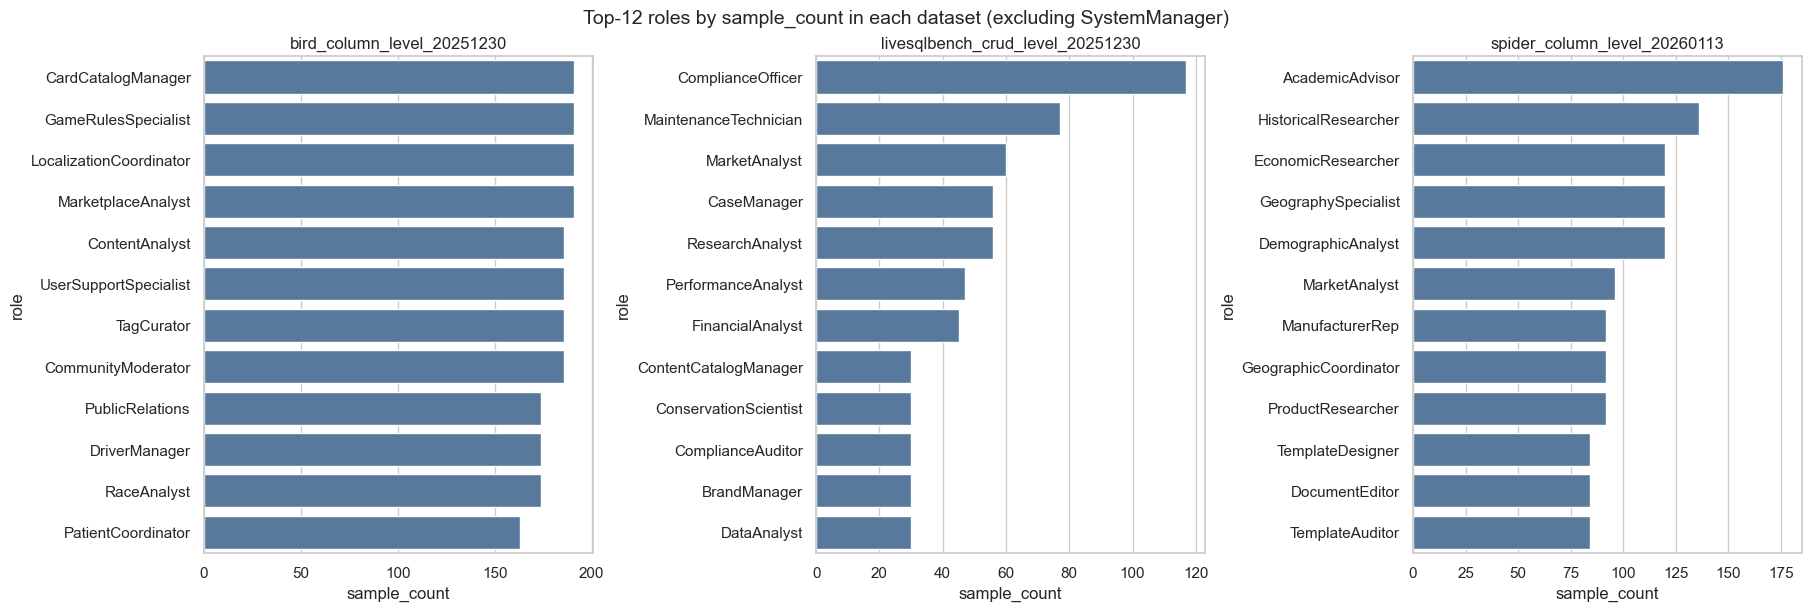

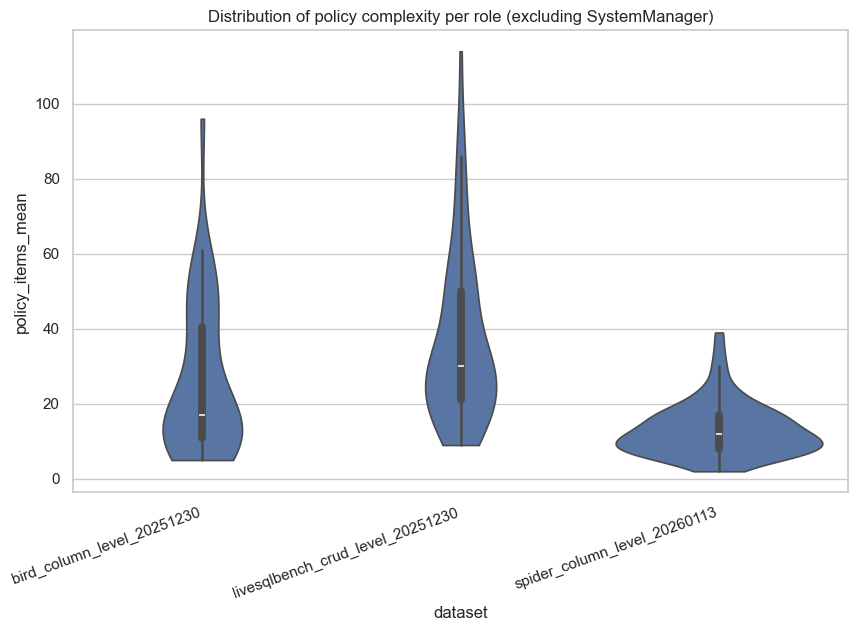

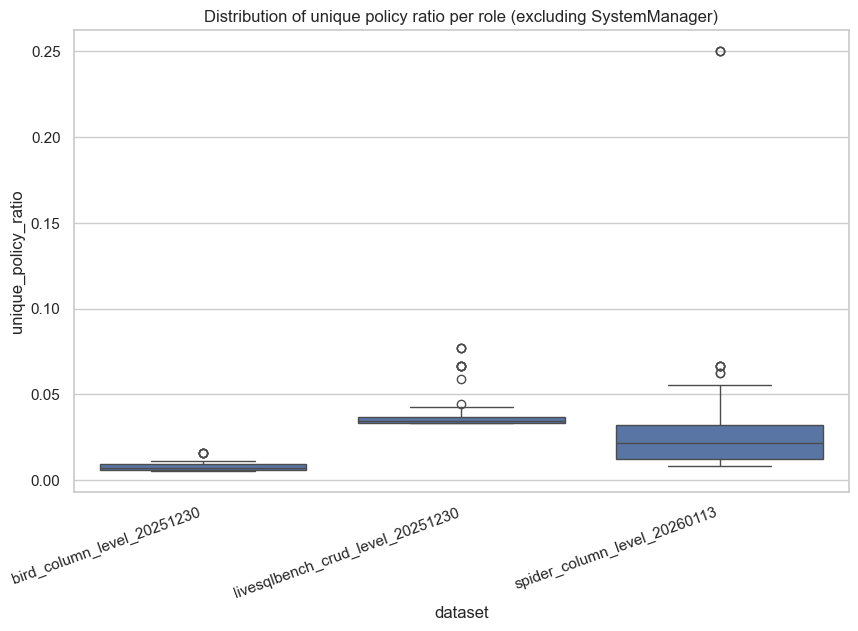

Saved figures:
- /home/feiy/Role-SQL-benchmark/outputs/analysis/policy_distribution_selected_20260314_193939/figures/role_sample_distribution_top12_no_systemmanager.png
- /home/feiy/Role-SQL-benchmark/outputs/analysis/policy_distribution_selected_20260314_193939/figures/policy_complexity_violin_no_systemmanager.png
- /home/feiy/Role-SQL-benchmark/outputs/analysis/policy_distribution_selected_20260314_193939/figures/unique_policy_ratio_boxplot_no_systemmanager.png


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
fig_dir = LATEST / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

# Figure 1: top role frequencies per dataset (excluding SystemManager)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
for ax, ds in zip(axes, role_dist_nosm['dataset'].unique()):
    tmp = role_dist_nosm[role_dist_nosm['dataset'] == ds].sort_values('sample_count', ascending=False).head(12)
    sns.barplot(data=tmp, y='role', x='sample_count', ax=ax, color='#4C78A8')
    ax.set_title(ds)
    ax.set_xlabel('sample_count')
    ax.set_ylabel('role')

fig.suptitle('Top-12 roles by sample_count in each dataset (excluding SystemManager)', fontsize=14)
out1 = fig_dir / 'role_sample_distribution_top12_no_systemmanager.png'
fig.savefig(out1, dpi=220, bbox_inches='tight')
plt.show()

# Figure 2: policy complexity distribution (excluding SystemManager)
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=role_stats_nosm, x='dataset', y='policy_items_mean', inner='box', cut=0, ax=ax)
ax.set_title('Distribution of policy complexity per role (excluding SystemManager)')
ax.set_xlabel('dataset')
ax.set_ylabel('policy_items_mean')
plt.xticks(rotation=20, ha='right')
out2 = fig_dir / 'policy_complexity_violin_no_systemmanager.png'
fig.savefig(out2, dpi=220, bbox_inches='tight')
plt.show()

# Figure 3: unique policy ratio distribution (excluding SystemManager)
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=role_dist_nosm, x='dataset', y='unique_policy_ratio', ax=ax)
ax.set_title('Distribution of unique policy ratio per role (excluding SystemManager)')
ax.set_xlabel('dataset')
ax.set_ylabel('unique_policy_ratio')
plt.xticks(rotation=20, ha='right')
out3 = fig_dir / 'unique_policy_ratio_boxplot_no_systemmanager.png'
fig.savefig(out3, dpi=220, bbox_inches='tight')
plt.show()

print('Saved figures:')
print('-', out1)
print('-', out2)
print('-', out3)

## Figures (role-policy distribution across three datasets)

This section produces publication-ready figures:

1. Role sample distribution (top roles per dataset)
2. Policy complexity distribution (`policy_items_mean`) by dataset
3. `unique_policy_ratio` distribution by dataset

All figures are saved under `LATEST/figures/`.

In [19]:
tex_dir = LATEST / 'tex'
tex_dir.mkdir(parents=True, exist_ok=True)

# Table 1: dataset-level compact report (excluding SystemManager)
t1 = role_stats_nosm.groupby(['dataset', 'level']).agg(
    roles=('role', 'count'),
    samples=('sample_count', 'sum'),
    mean_policy_items=('policy_items_mean', 'mean'),
    median_policy_items=('policy_items_median', 'median'),
    max_policy_items=('policy_items_max', 'max')
).reset_index()

t1_tex = t1.to_latex(index=False, float_format='%.3f')
(t1_path := tex_dir / 'table_dataset_summary_no_systemmanager.tex').write_text(t1_tex, encoding='utf-8')

# Table 2: top-10 high complexity roles per dataset (excluding SystemManager)
rows = []
for ds in role_stats_nosm['dataset'].unique():
    tmp = role_stats_nosm[role_stats_nosm['dataset'] == ds].sort_values('policy_items_mean', ascending=False).head(10)
    rows.append(tmp)
t2 = pd.concat(rows, ignore_index=True)

t2_tex = t2[['dataset', 'role', 'sample_count', 'policy_items_mean', 'policy_items_median', 'policy_items_max']].to_latex(index=False, float_format='%.3f')
(t2_path := tex_dir / 'table_top10_roles_by_policy_complexity_no_systemmanager.tex').write_text(t2_tex, encoding='utf-8')

# Figure include snippet
fig_snippet = r'''% ---- Figures generated by policy_distribution_selected_baseline.ipynb ----
\\begin{figure*}[t]
  \\centering
  \\includegraphics[width=0.98\\textwidth]{figures/role_sample_distribution_top12_no_systemmanager.png}
  \\caption{Top-12 roles by sample count in each dataset (excluding SystemManager).}
  \\label{fig:role_sample_dist_no_systemmanager}
\\end{figure*}

\\begin{figure}[t]
  \\centering
  \\includegraphics[width=0.9\\columnwidth]{figures/policy_complexity_violin_no_systemmanager.png}
  \\caption{Distribution of role-level policy complexity ($policy\\_items\\_mean$), excluding SystemManager.}
  \\label{fig:policy_complexity_no_systemmanager}
\\end{figure}

\\begin{figure}[t]
  \\centering
  \\includegraphics[width=0.9\\columnwidth]{figures/unique_policy_ratio_boxplot_no_systemmanager.png}
  \\caption{Distribution of unique-policy ratio across roles, excluding SystemManager.}
  \\label{fig:policy_uniqueness_no_systemmanager}
\\end{figure}
'''
(fig_tex_path := tex_dir / 'figures_snippet_no_systemmanager.tex').write_text(fig_snippet, encoding='utf-8')

print('Saved LaTeX files:')
print('-', t1_path)
print('-', t2_path)
print('-', fig_tex_path)

print('\nKey findings (excluding SystemManager):')
for _, row in t1.iterrows():
    print(f"- {row['dataset']}: roles={int(row['roles'])}, samples={int(row['samples'])}, mean_policy_items={row['mean_policy_items']:.2f}, max_policy_items={int(row['max_policy_items'])}")

Saved LaTeX files:
- /home/feiy/Role-SQL-benchmark/outputs/analysis/policy_distribution_selected_20260314_193939/tex/table_dataset_summary_no_systemmanager.tex
- /home/feiy/Role-SQL-benchmark/outputs/analysis/policy_distribution_selected_20260314_193939/tex/table_top10_roles_by_policy_complexity_no_systemmanager.tex
- /home/feiy/Role-SQL-benchmark/outputs/analysis/policy_distribution_selected_20260314_193939/tex/figures_snippet_no_systemmanager.tex

Key findings (excluding SystemManager):
- bird_column_level_20251230: roles=42, samples=5718, mean_policy_items=25.81, max_policy_items=96
- livesqlbench_crud_level_20251230: roles=87, samples=2625, mean_policy_items=36.89, max_policy_items=134
- spider_column_level_20260113: roles=70, samples=4013, mean_policy_items=13.11, max_policy_items=39


## LaTeX Tables and Key Conclusions

This section exports publication-ready LaTeX tables and prints concise findings.